# Car Price Prediction Machine Learning Model :

## Data Preprocessing and Feature engeneering :

In [71]:
# importing libraries 
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import seaborn as sns 
plt.style.use('ggplot')

In [183]:
# loading data 
filepath="../dataset/car data.csv"
df=pd.read_csv(filepath)

In [73]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [74]:
df.tail()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


In [75]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner'],
      dtype='str')

In [76]:
df.dtypes

Car_Name             str
Year               int64
Selling_Price    float64
Present_Price    float64
Driven_kms         int64
Fuel_Type            str
Selling_type         str
Transmission         str
Owner              int64
dtype: object

In [77]:
df['Year'].value_counts()

Year
2015    61
2016    50
2014    38
2017    35
2013    33
2012    23
2011    19
2010    15
2008     7
2009     6
2006     4
2005     4
2003     2
2007     2
2018     1
2004     1
Name: count, dtype: int64

In [78]:
df['Age']=pd.Timestamp.now().year-df['Year']

In [79]:
df.Fuel_Type.value_counts()

Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64

In [80]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner', 'Age'],
      dtype='str')

In [81]:
df.Selling_type.value_counts()

Selling_type
Dealer        195
Individual    106
Name: count, dtype: int64

In [82]:
df.Owner.value_counts()

Owner
0    290
1     10
3      1
Name: count, dtype: int64

In [83]:
df.shape

(301, 10)

In [84]:
# handiling missing values :
def nan_perc(df):
    '''
    computing the percentage of missing valus in the whole dataset as well as in
    each column
    '''
    total_cells=np.prod(df.shape)
    total_nan_col=df.isna().sum()
    total_rows=len(df)
    total_nan=sum(total_nan_col)
    print("Total percentage of nan :",(total_nan/total_cells)*100)
    print("Percentage of nan in each column :")
    print((total_nan_col/total_rows)*100)

In [85]:
nan_perc(df)

Total percentage of nan : 0.0
Percentage of nan in each column :
Car_Name         0.0
Year             0.0
Selling_Price    0.0
Present_Price    0.0
Driven_kms       0.0
Fuel_Type        0.0
Selling_type     0.0
Transmission     0.0
Owner            0.0
Age              0.0
dtype: float64


In [86]:
# dropping duplicates
df=df.drop_duplicates()

In [87]:
# handling categorical data :

# identifying categorical data :
df.dtypes

Car_Name             str
Year               int64
Selling_Price    float64
Present_Price    float64
Driven_kms         int64
Fuel_Type            str
Selling_type         str
Transmission         str
Owner              int64
Age                int64
dtype: object

In [88]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


In [89]:
df.dtypes

Car_Name             str
Year               int64
Selling_Price    float64
Present_Price    float64
Driven_kms         int64
Fuel_Type            str
Selling_type         str
Transmission         str
Owner              int64
Age                int64
dtype: object

In [90]:
df.shape

(299, 10)

In [91]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner', 'Age'],
      dtype='str')

In [94]:
heatmap_data=df[['Selling_Price', 'Present_Price', 'Driven_kms',
       'Owner', 'Age']].corr()

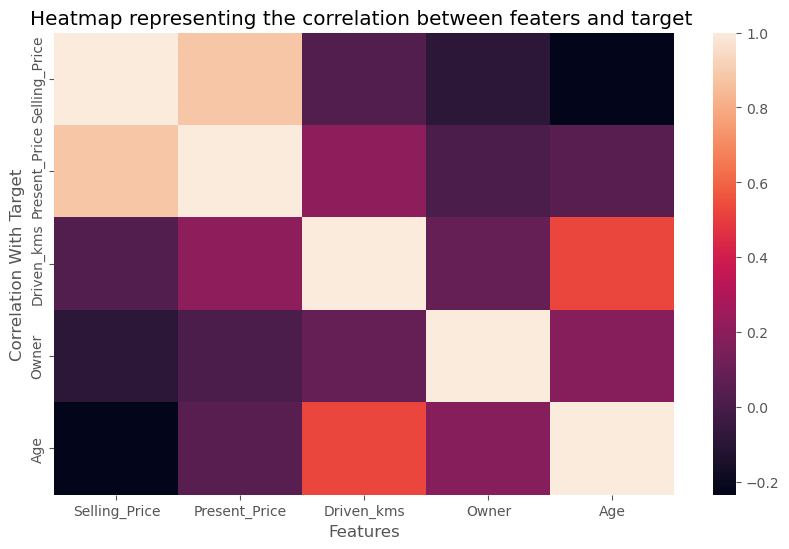

In [95]:
plt.figure(figsize=(10,6))
sns.heatmap(heatmap_data)
plt.xlabel('Features')
plt.ylabel('Correlation With Target')
plt.title('Heatmap representing the correlation between featers and target ')
plt.show()

## Model Training ,Testing and Improvement :

In [102]:
# 1. Drop the target column
d= df.drop('Car_Name', axis=1)

# 2. Encode the categorical columns
d= pd.get_dummies(d, columns=['Fuel_Type', 'Selling_type', 'Transmission'], dtype=int)

In [103]:
#picking only relevent features that affect the selling price 
features_1=['Present_Price','Year' ,'Driven_kms',
       'Owner', 'Fuel_Type_CNG', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol',
       'Selling_type_Dealer', 'Selling_type_Individual',
       'Transmission_Automatic', 'Transmission_Manual']
X_1=d[features_1]
y_1=d.Selling_Price

In [179]:
# importing libraries needed to train and test the model
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
# split the dataset into training data and testing/validation data
train_X_1, val_X_1, train_y_1, val_y_1 = train_test_split(X_1, y_1, random_state=1)
# creating the model ( random forest regressor )
rf_model_1 = RandomForestRegressor(random_state=1)
# fitting the model
rf_model_1.fit(train_X_1, train_y_1)
# using the model to give predictions regarding the validation input data
rf_val_predictions_1 = rf_model_1.predict(val_X_1)
# calculating the mae of the predictions to test the accuracy of the model 
rf_val_mae_1 = mean_absolute_error(rf_val_predictions_1, val_y_1)
print(rf_val_mae_1)

0.5907320000000004


In [105]:
#picking only relevent features that affect the selling price 
features_2=['Present_Price', 'Driven_kms',
       'Owner', 'Age', 'Fuel_Type_CNG', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol',
       'Selling_type_Dealer', 'Selling_type_Individual',
       'Transmission_Automatic', 'Transmission_Manual']
X_2=d[features_2]
y_2=d.Selling_Price

In [106]:
# importing libraries needed to train and test the model
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
# split the dataset into training data and testing/validation data
train_X_2, val_X_2, train_y_2, val_y_2 = train_test_split(X_2, y_2, random_state=1)
# creating the model ( random forest regressor )
rf_model_2 = RandomForestRegressor(random_state=1)
# fitting the model
rf_model_2.fit(train_X_2, train_y_2)
# using the model to give predictions regarding the validation input data
rf_val_predictions_2 = rf_model_2.predict(val_X_2)
# calculating the mae of the predictions to test the accuracy of the model 
rf_val_mae_2 = mean_absolute_error(rf_val_predictions_2, val_y_2)
print(rf_val_mae_2)

0.6000280000000006


In [108]:
df.Selling_Price.describe()

count    299.000000
mean       4.589632
std        4.984240
min        0.100000
25%        0.850000
50%        3.510000
75%        6.000000
max       35.000000
Name: Selling_Price, dtype: float64

In [109]:
rf_model=rf_model_1
features=features_1
X=X_1
y=y_1

In [110]:
df.dtypes

Car_Name             str
Year               int64
Selling_Price    float64
Present_Price    float64
Driven_kms         int64
Fuel_Type            str
Selling_type         str
Transmission         str
Owner              int64
Age                int64
dtype: object

In [111]:
df.columns


Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner', 'Age'],
      dtype='str')

In [112]:
# categorizing columns into numerical and categorical
columns=df[['Year', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner']].columns
numerical_columns=df[['Car_Name', 'Year', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner']].select_dtypes(exclude='str').columns
categorical_columns=[ col for col in columns if col not in numerical_columns]

In [113]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner', 'Age'],
      dtype='str')

In [114]:
# using piplines 
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
# imputing numerical columns
numerical_transformer=SimpleImputer(strategy='median')
# imputing categorical columns +one hot encoding them
# dropping categorical columns that have a variety of unique values that are very likely to introduce new categories in the new data
def dropping(df,col):
    df=df.drop(columns=col)
categorical_transformer=Pipeline(steps=[
    ('drop',dropping(df,'Car_Name')),
    ('imputation',SimpleImputer(strategy='most_frequent')),
    ('onehot',OneHotEncoder(handle_unknown='ignore'))]
)
# combining both numerical columns processor with categorical column ones as a single processor
preprocessor=ColumnTransformer(transformers=[
    ('num',numerical_transformer,numerical_columns),
    ('cat',categorical_transformer,categorical_columns)
]
)


In [115]:
# now it is time to glue the model to the preprocessor
from sklearn.ensemble import RandomForestRegressor 
model=RandomForestRegressor(n_estimators=100,random_state=42)
pipeline=Pipeline(steps=[
    ('preprocessing',preprocessor),
    ('model',model)
])

In [116]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner', 'Age'],
      dtype='str')

In [117]:
# now lets split data then train the model 
from sklearn.model_selection import train_test_split
feature=['Car_Name', 'Year', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner']
X=df[feature]
y=df['Selling_Price']
train_X,test_X,train_y,test_y=train_test_split(X,y, test_size=0.2, random_state=42)
pipeline.fit(train_X,train_y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['Car_Name','Year','Present_Price',...,'Selling_type','Transmission', 'Owner']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of c

In [118]:
# validation of model 
from sklearn.metrics import mean_absolute_error
predictions=pipeline.predict(test_X)
mae=mean_absolute_error(predictions,test_y)
print('mean absolute error :',mae)

mean absolute error : 1.5450350000000008


In [175]:
# enhancing the model further using extre&e gradient booster 
import xgboost as xgb
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
# 1. Drop useless columns
#df = df.drop(columns='Car_Name')

# 2. Build the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='mean'), ['Year', 'Present_Price', 'Driven_kms', 'Owner']),
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['Fuel_Type', 'Selling_type', 'Transmission'])
    ]
)

# 3. Split data (You must split FIRST!)
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Preprocess the data manually (No Pipeline!)
train_X = preprocessor.fit_transform(train_X)
test_X = preprocessor.transform(test_X)

# 5. Train the model directly (No Pipeline!)
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(
    train_X, 
    train_y, 
)

# 6. Evaluate
print(f"MAE: {mean_absolute_error(test_y, xgb_model.predict(test_X)):.2f}")

MAE: 1.05


In [176]:
from sklearn.pipeline import Pipeline

# 1. Build the pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', xgb_model)
])

# 2. Cross-validate the pipeline (It auto-preprocesses the data!)
scores = -1*cross_val_score(pipeline, X, y, cv=5, scoring='neg_mean_absolute_error')

In [177]:
print(scores)

[0.68837694 1.97264239 0.17197815 0.62814832 0.97535067]


In [178]:
print(scores.mean())

0.88729929465564


In [180]:
# 5. Train the model directly (No Pipeline!)
model = xgb.XGBRegressor(n_estimators=1000, learning_rate=0.1, random_state=42,early_stopping_rounds=5)
model.fit(
    train_X, 
    train_y,
    eval_set=[(test_X, test_y)],
    verbose=False
)

# 6. Evaluate
print(f"MAE: {mean_absolute_error(test_y, xgb_model.predict(test_X)):.2f}")

MAE: 1.05
